In [1]:
import os
os.chdir('/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning')
print("Current working directory: {0}".format(os.getcwd()))

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
%autoreload 2

Current working directory: /Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning


In [2]:
import time 
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.datasets import make_moons, make_circles, make_classification
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.model_selection import train_test_split
from toma import toma
import math
from dataclasses import dataclass
from typing import List

import pickle

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler
from torch.utils.data import DataLoader, Subset
import torch.utils.data as data


from src.models.model import MLP
from src.data.data import get_dataloaders, TwoMoons
from src.models.train_model import train, test

torch.manual_seed(0)
np.random.seed(1)
random.seed(0)

# Set device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [3]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle
import torch.utils.data as data

from src.data.data import MNIST_CUSTOM

In [4]:
from batchbald_redux import (
        active_learning,
        batchbald,
        consistent_mc_dropout,
        joint_entropy,
        repeated_mnist,
    )

In [5]:
class BayesianCNN(consistent_mc_dropout.BayesianModule):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv1_drop = consistent_mc_dropout.ConsistentMCDropout2d()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=5)
        self.conv2_drop = consistent_mc_dropout.ConsistentMCDropout2d()
        self.fc1 = nn.Linear(1024, 128)
        self.fc1_drop = consistent_mc_dropout.ConsistentMCDropout()
        self.fc2 = nn.Linear(128, num_classes)

    def mc_forward_impl(self, input: torch.Tensor):
        input = F.relu(F.max_pool2d(self.conv1_drop(self.conv1(input)), 2))
        input = F.relu(F.max_pool2d(self.conv2_drop(self.conv2(input)), 2))
        input = input.view(-1, 1024)
        input = F.relu(self.fc1_drop(self.fc1(input)))
        input = self.fc2(input)
        input = F.log_softmax(input, dim=1)

        return input

In [6]:
num_classes = 10
num_initial_samples = 20

batch_list = [4, 8, 16, 32]
algo_list = ["bald", "batchbald"]
final_test_accs = []
final_indices = []

max_training_samples = 180  # Maximum limit of train samples needed
num_inference_samples = 10
num_test_inference_samples = 5
num_samples = 100000  # Total number of samples

test_batch_size = 512  # Test Loader Batch size
batch_size = 64  # Train loader Batch size
scoring_batch_size = 128  # Pool Loader Batch size
training_iterations = 4096 * 6

use_cuda = torch.cuda.is_available()
print(f"use_cuda: {use_cuda}")
device = "cuda" if use_cuda else "cpu"
kwargs = {"num_workers": 0, "pin_memory": True} if use_cuda else {}


use_cuda: False


In [7]:
# get an active learning dataset
mnist_train = MNIST(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST(root='./data/raw', train=False, transform=transforms.ToTensor())
testloader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=0)

active_learning_data = active_learning.ActiveLearningData(mnist_train)

In [8]:
initial_samples = active_learning.get_balanced_sample_indices(
            repeated_mnist.get_targets(mnist_train),
            num_classes=num_classes,
            n_per_digit=num_initial_samples / num_classes,
        )

active_learning_data.acquire(
            initial_samples
        )  # Seperates the initial indices from the pool and fixes it as initial train dataset

In [9]:
print(len(active_learning_data.training_dataset))
print(len(active_learning_data.pool_dataset))


train_loader = torch.utils.data.DataLoader(
            active_learning_data.training_dataset,
            sampler=active_learning.RandomFixedLengthSampler(
                active_learning_data.training_dataset, training_iterations
            ),
            batch_size=batch_size,
            **kwargs,
        )

pool_loader = torch.utils.data.DataLoader(
            active_learning_data.pool_dataset,
            batch_size=scoring_batch_size,
            shuffle=False,
            **kwargs,
        )

20
59980


In [10]:
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=test_batch_size, shuffle=False, **kwargs)

In [11]:
# get an active learning dataset
mnist_train = MNIST(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST(root='./data/raw', train=False, transform=transforms.ToTensor())
test_loader = DataLoader(mnist_test, batch_size=test_batch_size, shuffle=False, **kwargs)

active_learning_data = active_learning.ActiveLearningData(mnist_train)

initial_samples = active_learning.get_balanced_sample_indices(
            repeated_mnist.get_targets(mnist_train),
            num_classes=num_classes,
            n_per_digit=num_initial_samples / num_classes,
        )

active_learning_data.acquire(
            initial_samples
        )  # Seperates the initial indices from the pool and fixes it as initial train dataset


print(len(active_learning_data.training_dataset))
print(len(active_learning_data.pool_dataset))


test_accs = []
test_loss = []
added_indices = []

acquisition_batch_size = 10
num_queries = 10
type = 'batchbald'

pbar = tqdm(
            initial=len(active_learning_data.training_dataset),
            total=max_training_samples,
            desc="Training Set Size",
        )
for query in range(num_queries):
    model = BayesianCNN(num_classes).to(device=device)  # initialise model
    optimizer = torch.optim.Adam(model.parameters())

    model.train()

    # Train
    for data, target in tqdm(train_loader, desc="Training", leave=False):
        data = data.to(device=device)
        target = target.to(device=device)

        optimizer.zero_grad()

        prediction = model(data, 1).squeeze(1)
        loss = F.nll_loss(prediction, target)

        loss.backward()
        optimizer.step()

    # Test
    loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc="Testing", leave=False):
            data = data.to(device=device)
            target = target.to(device=device)

            prediction = torch.logsumexp(model(data, num_test_inference_samples), dim=1) - math.log(
                num_test_inference_samples
            )
            loss += F.nll_loss(prediction, target, reduction="sum")

            prediction = prediction.max(1)[1]
            correct += prediction.eq(target.view_as(prediction)).sum().item()

    loss /= len(test_loader.dataset)
    test_loss.append(loss)

    percentage_correct = 100.0 * correct / len(test_loader.dataset)
    test_accs.append(percentage_correct)

    print("Test set: Average loss: {:.4f}, Accuracy: ({:.2f}%)".format(loss, percentage_correct))

    if len(active_learning_data.training_dataset) >= max_training_samples:
        break

    # Acquire pool predictions
    N = len(active_learning_data.pool_dataset)
    logits_N_K_C = torch.empty(
        (N, num_inference_samples, num_classes),
        dtype=torch.double,
        pin_memory=use_cuda,
    )

    with torch.no_grad():
        model.eval()

        for i, (data, _) in enumerate(tqdm(pool_loader, desc="Evaluating Acquisition Set", leave=False)):
            data = data.to(device=device)

            lower = i * pool_loader.batch_size
            upper = min(lower + pool_loader.batch_size, N)
            logits_N_K_C[lower:upper].copy_(model(data, num_inference_samples).double(), non_blocking=True)

    with torch.no_grad():
        if type == "batchbald":
            candidate_batch = batchbald.get_batchbald_batch(
                logits_N_K_C,
                acquisition_batch_size,
                num_samples,
                dtype=torch.double,
                device=device,  # Returns the indices and scores(Mutual Information) for the batch selected by Batchbald/BALD Strategy.
            )

        elif type == "bald":
            candidate_batch = batchbald.get_bald_batch(
                logits_N_K_C,
                acquisition_batch_size,
                dtype=torch.double,
                device=device,
            )

    targets = repeated_mnist.get_targets(active_learning_data.pool_dataset)  # Returns the target labels
    dataset_indices = active_learning_data.get_dataset_indices(
        candidate_batch.indices
    )  # Returns indices for candidate batch

    print("Dataset indices: ", dataset_indices)
    # print("Scores: ", candidate_batch.scores)
    print("Labels: ", targets[candidate_batch.indices])

    active_learning_data.acquire(candidate_batch.indices)  # add the new indices to training dataset
    added_indices.append(dataset_indices)
    pbar.update(len(dataset_indices))

20
59980


Training Set Size:  11%|█         | 20/180 [00:00<?, ?it/s]

Test set: Average loss: 1.7870, Accuracy: (59.14%)


Conditional Entropy:   0%|          | 0/59980 [00:00<?, ?it/s]

BatchBALD:   0%|          | 0/10 [00:00<?, ?it/s]

...

ExactJointEntropy.compute_batch:   0%|          | 0/59980 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59980 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59980 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59980 [00:00<?, ?it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/59980 [00:00<?, ?it/s]

In [ ]:
num_inference_samples = 100
num_test_inference_samples = 5
num_samples = 100000  # Total number of samples

test_batch_size = 512  # Test Loader Batch size
batch_size = 64  # Train loader Batch size
scoring_batch_size = 128  # Pool Loader Batch size
training_iterations = 4096 * 6

use_cuda = torch.cuda.is_available()
print(f"use_cuda: {use_cuda}")
device = "cuda" if use_cuda else "cpu"
kwargs = {"num_workers": 0, "pin_memory": True} if use_cuda else {}

In [ ]:
def entire_batchbald_run(traindata: data.Dataset,
                         initial_samples: List(),
                         acquisition_batch_size = 10,
                         num_queries = 10,
                         type = 'batchbald'             
                         ):
    active_learning_data = active_learning.ActiveLearningData(traindata)
    active_learning_data.acquire(
            initial_samples
        )  
    
    print(f'Length of trainset: {len(active_learning_data.training_dataset)}')
    print(f'Length of poolset: {len(active_learning_data.pool_dataset)}')
    
    train_loader = torch.utils.data.DataLoader(
            active_learning_data.training_dataset,
            sampler=active_learning.RandomFixedLengthSampler(
                active_learning_data.training_dataset, training_iterations
            ),
            batch_size=batch_size,
            **kwargs,
        )

    pool_loader = torch.utils.data.DataLoader(
                active_learning_data.pool_dataset,
                batch_size=scoring_batch_size,
                shuffle=False,
                **kwargs,
            )
        
    test_accs = []
    test_loss = []
    added_indices = []
    
    pbar = tqdm(
            initial=len(active_learning_data.training_dataset),
            #total=max_training_samples,
            desc="Training Set Size",
        )
    
    for query in range(num_queries):
        model = BayesianCNN(num_classes).to(device=device)  # initialise model
        optimizer = torch.optim.Adam(model.parameters())

        model.train()

        # Train
        for data, target in tqdm(train_loader, desc="Training", leave=False):
            data = data.to(device=device)
            target = target.to(device=device)

            optimizer.zero_grad()

            prediction = model(data, 1).squeeze(1)
            loss = F.nll_loss(prediction, target)

            loss.backward()
            optimizer.step()

        # Test
        loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in tqdm(test_loader, desc="Testing", leave=False):
                data = data.to(device=device)
                target = target.to(device=device)

                prediction = torch.logsumexp(model(data, num_test_inference_samples), dim=1) - math.log(
                    num_test_inference_samples
                )
                loss += F.nll_loss(prediction, target, reduction="sum")

                prediction = prediction.max(1)[1]
                correct += prediction.eq(target.view_as(prediction)).sum().item()

        loss /= len(test_loader.dataset)
        test_loss.append(loss)

        percentage_correct = 100.0 * correct / len(test_loader.dataset)
        test_accs.append(percentage_correct)

        print("Test set: Average loss: {:.4f}, Accuracy: ({:.2f}%)".format(loss, percentage_correct))

        # Acquire pool predictions
        N = len(active_learning_data.pool_dataset)
        logits_N_K_C = torch.empty(
            (N, num_inference_samples, num_classes),
            dtype=torch.double,
            pin_memory=use_cuda,
        )

        with torch.no_grad():
            model.eval()

            for i, (data, _) in enumerate(tqdm(pool_loader, desc="Evaluating Acquisition Set", leave=False)):
                data = data.to(device=device)

                lower = i * pool_loader.batch_size
                upper = min(lower + pool_loader.batch_size, N)
                logits_N_K_C[lower:upper].copy_(model(data, num_inference_samples).double(), non_blocking=True)

        with torch.no_grad():
            if type == "batchbald":
                candidate_batch = batchbald.get_batchbald_batch(
                    logits_N_K_C,
                    acquisition_batch_size,
                    num_samples,
                    dtype=torch.double,
                    device=device,  # Returns the indices and scores(Mutual Information) for the batch selected by Batchbald/BALD Strategy.
                )

            elif type == "bald":
                candidate_batch = batchbald.get_bald_batch(
                    logits_N_K_C,
                    acquisition_batch_size,
                    dtype=torch.double,
                    device=device,
                )

        dataset_indices = active_learning_data.get_dataset_indices(
            candidate_batch.indices
        )  # Returns indices for candidate batch

        print("Dataset indices: ", dataset_indices)

        active_learning_data.acquire(candidate_batch.indices)  # add the new indices to training dataset
        added_indices.append(dataset_indices)
        pbar.update(len(dataset_indices))

In [ ]:
num_classes = 10
num_initial_samples = 20

initial_samples = active_learning.get_balanced_sample_indices(
            repeated_mnist.get_targets(mnist_train),
            num_classes=num_classes,
            n_per_digit=num_initial_samples / num_classes,
        )

entire_batchbald_run(mnist_train, )

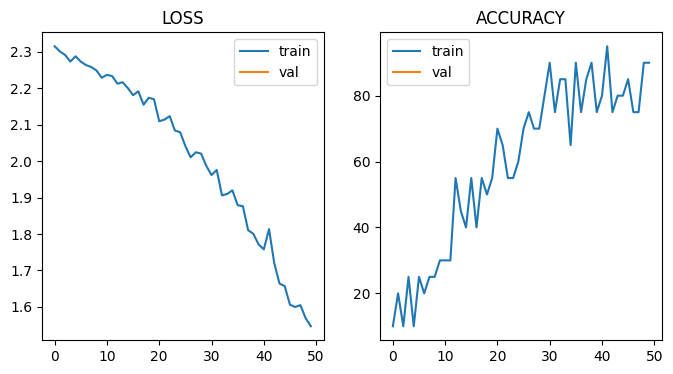

Query [7/20]:  40%|████      | 8/20 [00:38<00:57,  4.76s/it, test_acc=88.5]


KeyboardInterrupt: 

In [5]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle

TEST_ACC = []

# AL parameters
num_queries = 20
query_size = 50
T = 30

# get an active learning dataset
mnist_train = MNIST_CUSTOM(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST_CUSTOM(root='./data/raw', train=False, transform=transforms.ToTensor())
testloader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=0)

al_dataset = ActiveLearningDataset(mnist_train)

# call to get balanced initial pool
al_dataset.get_initial_balanced_trainset(n_per_class=2)

# define model
model = PaperCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
trainloader = DataLoader(al_dataset.training_dataset, batch_size=256, shuffle=False, num_workers=0)

# train on initial pool 
model, optimizer = train(model, trainloader, optimizer, device, num_epochs=50, val = False, plot = True, printout = False)

TEST_ACC.append(test(model, testloader, device, display=False))

# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:
    
    # query data points from unlabeled pool
    query_batch = query_the_oracle(device,
                                      model,
                                      al_dataset.pool_dataset,
                                      T = T,
                                      query_size=query_size,
                                      query_strategy= 'random',
                                      bald_method='MC_drop'
                                  )
    
    # update labeled pool with queried data points
    al_dataset.acquire_samples(query_batch.indices)
    
    # train on labeled pool subset
    labeled_loader = DataLoader(al_dataset.training_dataset, batch_size=256, num_workers=0,shuffle = False)
    model, optimizer = train(model, labeled_loader, optimizer, device, num_epochs=50, val = False, plot = False, printout = False)
    acc = test(model, testloader, device, display = False)
    
    # test model
    test_acc = test(model, testloader, device, display=False)
    TEST_ACC.append(test_acc)
    
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    
    

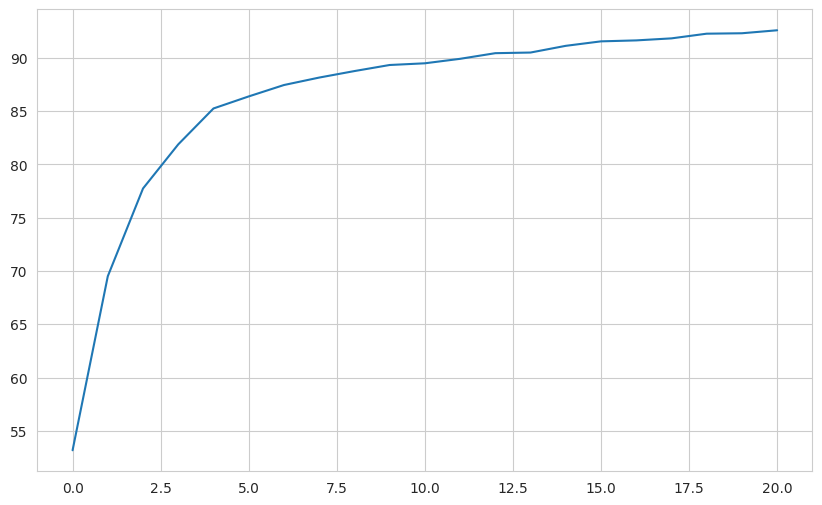

In [5]:
plt.figure(figsize=(10,6))

with sns.axes_style("whitegrid"):
    plt.plot(TEST_ACC)

In [ ]:
import numpy as np


def get_mixture_prob_dist(p1, p2, m):
    return (1.0 - m) * np.asarray(p1) + m * np.asarray(p2)

K = 20

p1 = [0.7, 0.1, 0.1, 0.1]
p2 = [0.3, 0.3, 0.2, 0.2]
y1_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.7, 0.1, 0.1]
p2 = [0.2, 0.3, 0.3, 0.2]
y2_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.1, 0.7, 0.1]
p2 = [0.2, 0.2, 0.3, 0.3]
y3_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.1, 0.1, 0.7]
p2 = [0.3, 0.2, 0.2, 0.3]
y4_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]


def nested_to_tensor(l):
    return torch.stack(list(map(torch.as_tensor, l)))


ys_ws = nested_to_tensor([y1_ws, y2_ws, y3_ws, y4_ws])

/var/folders/dd/s080ztxj4q50zd2xnnx6t0t40000gn/T/ipykernel_7363/2584744409.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:233.)
  return torch.stack(list(map(torch.as_tensor, l)))


In [ ]:
ys_ws.shape

torch.Size([4, 20, 4])

In [ ]:
# hide

p = [0.25, 0.25, 0.25, 0.25]
yu_ws = [p for m in range(K)]
yus_ws = nested_to_tensor([yu_ws] * 4)

In [ ]:
def compute_conditional_entropy(probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Conditional Entropy", leave=False)

    @toma.execute.chunked(probs_N_K_C, 1024)
    def compute(probs_n_K_C, start: int, end: int):
        nats_n_K_C = probs_n_K_C * torch.log(probs_n_K_C)
        nats_n_K_C[probs_n_K_C == 0] = 0.0

        entropies_N[start:end].copy_(-torch.sum(nats_n_K_C, dim=(1, 2)) / K)
        pbar.update(end - start)

    pbar.close()

    return entropies_N


def compute_entropy(probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Entropy", leave=False)

    @toma.execute.chunked(probs_N_K_C, 1024)
    def compute(probs_n_K_C, start: int, end: int):
        mean_probs_n_C = probs_n_K_C.mean(dim=1)
        nats_n_C = mean_probs_n_C * torch.log(mean_probs_n_C)
        nats_n_C[mean_probs_n_C == 0] = 0.0

        entropies_N[start:end].copy_(-torch.sum(nats_n_C, dim=1))
        pbar.update(end - start)

    pbar.close()

    return entropies_N

In [ ]:

# Make sure everything is computed correctly.

assert np.allclose(compute_conditional_entropy(yus_ws), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)
assert np.allclose(compute_entropy(yus_ws), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)

In [ ]:
# exports


def compute_conditional_entropy(log_probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = log_probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Conditional Entropy", leave=False)

    @toma.execute.chunked(log_probs_N_K_C, 1024)
    def compute(log_probs_n_K_C, start: int, end: int):
        nats_n_K_C = log_probs_n_K_C * torch.exp(log_probs_n_K_C)

        entropies_N[start:end].copy_(-torch.sum(nats_n_K_C, dim=(1, 2)) / K)
        pbar.update(end - start)

    pbar.close()

    return entropies_N


def compute_entropy(log_probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = log_probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Entropy", leave=False)

    @toma.execute.chunked(log_probs_N_K_C, 1024)
    def compute(log_probs_n_K_C, start: int, end: int):
        mean_log_probs_n_C = torch.logsumexp(log_probs_n_K_C, dim=1) - math.log(K)
        nats_n_C = mean_log_probs_n_C * torch.exp(mean_log_probs_n_C)

        entropies_N[start:end].copy_(-torch.sum(nats_n_C, dim=1))
        pbar.update(end - start)

    pbar.close()

    return entropies_N

In [ ]:
# hide

# Make sure everything is computed correctly.
assert np.allclose(compute_conditional_entropy(yus_ws.log()), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)
assert np.allclose(compute_entropy(yus_ws.log()), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)

In [ ]:
conditional_entropies = compute_conditional_entropy(ys_ws.log())

print(conditional_entropies)

assert np.allclose(conditional_entropies, [1.2069, 1.2069, 1.2069, 1.2069], atol=0.01)

tensor([1.2069, 1.2069, 1.2069, 1.2069], dtype=torch.float64)


In [ ]:
entropies = compute_entropy(ys_ws.log())

print(entropies)

assert np.allclose(entropies, [1.2376, 1.2376, 1.2376, 1.2376], atol=0.01)

tensor([1.2376, 1.2376, 1.2376, 1.2376], dtype=torch.float64)


In [ ]:
# exports
import src.models.joint_entropy as joint_entropy

@dataclass
class CandidateBatch:
    scores: List[float]
    indices: List[int]


def get_batchbald_batch(
    log_probs_N_K_C: torch.Tensor, batch_size: int, num_samples: int, dtype=None, device=None
) -> CandidateBatch:
    N, K, C = log_probs_N_K_C.shape

    batch_size = min(batch_size, N)

    candidate_indices = []
    candidate_scores = []

    if batch_size == 0:
        return CandidateBatch(candidate_scores, candidate_indices)

    conditional_entropies_N = compute_conditional_entropy(log_probs_N_K_C)

    batch_joint_entropy = joint_entropy.DynamicJointEntropy(
        num_samples, batch_size - 1, K, C, dtype=dtype, device=device
    )

    # We always keep these on the CPU.
    scores_N = torch.empty(N, dtype=torch.double, pin_memory=torch.cuda.is_available())

    for i in tqdm(range(batch_size), desc="BatchBALD", leave=False):
        if i > 0:
            latest_index = candidate_indices[-1]
            batch_joint_entropy.add_variables(log_probs_N_K_C[latest_index : latest_index + 1])

        shared_conditinal_entropies = conditional_entropies_N[candidate_indices].sum()

        batch_joint_entropy.compute_batch(log_probs_N_K_C, output_entropies_B=scores_N)

        scores_N -= conditional_entropies_N + shared_conditinal_entropies
        scores_N[candidate_indices] = -float("inf")

        candidate_score, candidate_index = scores_N.max(dim=0)

        candidate_indices.append(candidate_index.item())
        candidate_scores.append(candidate_score.item())

    return CandidateBatch(candidate_scores, candidate_indices)

In [ ]:
get_batchbald_batch(ys_ws.log().double(), 4, 1000, dtype=torch.double)

BatchBALD:   0%|          | 0/4 [00:00<?, ?it/s]          

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  25%|██▌       | 1/4 [00:00<00:00,  5.94it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  50%|█████     | 2/4 [00:00<00:00,  6.30it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  75%|███████▌  | 3/4 [00:00<00:00,  6.38it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

CandidateBatch(scores=[0.030715639666234695, 0.05961958627158248, 0.0869107051474467, 0.11275304532467789], indices=[0, 1, 2, 3])

In [ ]:


def get_bald_batch(log_probs_N_K_C: torch.Tensor, batch_size: int, dtype=None, device=None) -> CandidateBatch:
    N, K, C = log_probs_N_K_C.shape

    batch_size = min(batch_size, N)

    candidate_indices = []
    candidate_scores = []

    scores_N = -compute_conditional_entropy(log_probs_N_K_C)
    scores_N += compute_entropy(log_probs_N_K_C)

    candiate_scores, candidate_indices = torch.topk(scores_N, batch_size)

    return CandidateBatch(candiate_scores.tolist(), candidate_indices.tolist())

In [ ]:
get_bald_batch(ys_ws.log().double(), 4)

CandidateBatch(scores=[0.030715639666234917, 0.030715639666234917, 0.030715639666234917, 0.030715639666234695], indices=[0, 1, 2, 3])